# NB05: Formulation Optimization

**Project**: CF Protective Microbiome Formulation Design  
**Goal**: Test H2 — design and rank optimal 1–5 organism formulations using multi-criterion optimization.

A good formulation: (1) collectively covers PA14's carbon niche, (2) members don't compete with each other, (3) species are prevalent/active in patients, (4) measured inhibition is high, (5) all members are FDA-safe.

**Input**: `data/single_isolate_scores.tsv` (NB03), `data/species_engraftability.tsv` (NB04)  
**Output**: `data/formulations_ranked.tsv`

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

DATA = Path('..') / 'data'
FIGS = Path('..') / 'figures'
GOLD = Path.home() / 'protect' / 'gold'

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

scores = pd.read_csv(DATA / 'single_isolate_scores.tsv', sep='\t')
engraft = pd.read_csv(DATA / 'species_engraftability.tsv', sep='\t', index_col=0)
isolates_full = pd.read_parquet(GOLD / 'dim_isolate.snappy.parquet')

print(f'Isolates with scores: {len(scores)}')
print(f'Species with engraftability: {len(engraft)}')

Isolates with scores: 429
Species with engraftability: 134


## 1. Candidate Pool After Filtering

In [2]:
# Filter: safe, has inhibition data, positive inhibition
candidates = scores[(scores.is_safe == True) & 
                    (scores.has_inhibition == True) & 
                    (scores.best_pct_inhibition > 0)].copy()
print(f'Candidates after safety + inhibition filter: {len(candidates)}')
print(f'Species: {candidates.species.nunique()}')
print(f'\nInhibition range: {candidates.best_pct_inhibition.min():.1f}% to {candidates.best_pct_inhibition.max():.1f}%')

# Add engraftability (match by species name to bridge)
bridge = pd.read_parquet(GOLD / 'bridge_isolate_metagenomics.snappy.parquet')
# Create species-to-metagenomics map
species_engraft_map = {}
for _, row in bridge.iterrows():
    taxon = row['isolate_taxon']
    metag_feat = row['metagenomic_feature']
    if metag_feat in engraft.index:
        species_engraft_map[taxon] = engraft.loc[metag_feat, 'engraftability']

candidates['engraftability'] = candidates.species.map(species_engraft_map).fillna(0)
print(f'Candidates with engraftability > 0: {(candidates.engraftability > 0).sum()}')

Candidates after safety + inhibition filter: 120
Species: 54

Inhibition range: 0.6% to 101.6%
Candidates with engraftability > 0: 42


In [3]:
pa14_preferred = ['proline', 'histidine', 'ornithine', 'glutamate', 'aspartate',
                  'isoleucine', 'arginine', 'lactate', 'leucine', 'alanine', 'glucose']
carbon_sources = ['glucose', 'lactate', 'serine', 'threonine', 'alanine',
                  'glycine', 'proline', 'isoleucine', 'leucine', 'valine', 'aspartate',
                  'glutamate', 'phenylalanine', 'tryptophan', 'lysine', 'histidine',
                  'arginine', 'ornithine', 'cystein', 'methionine']

def score_formulation(isolate_ids, candidates_df, growth_threshold=0.1):
    """Score a formulation of 1-5 isolates."""
    members = candidates_df[candidates_df.asma_id.isin(isolate_ids)]
    if len(members) == 0:
        return None
    
    # PA niche coverage: fraction of PA14-preferred substrates with at least one member growing
    covered = 0
    for sub in pa14_preferred:
        if (members[sub] > growth_threshold).any():
            covered += 1
    niche_coverage = covered / len(pa14_preferred)
    
    # Internal complementarity: 1 - mean pairwise cosine similarity on carbon profiles
    if len(members) >= 2:
        profiles = members[carbon_sources].values
        from sklearn.metrics.pairwise import cosine_similarity
        sim_matrix = cosine_similarity(profiles)
        # Mean of upper triangle (exclude diagonal)
        n = len(profiles)
        triu_idx = np.triu_indices(n, k=1)
        mean_sim = sim_matrix[triu_idx].mean()
        complementarity = 1 - mean_sim
    else:
        complementarity = 1.0  # single organism = no self-competition
    
    # Mean inhibition
    mean_inh = members.best_pct_inhibition.mean() / 100
    
    # Engraftability (geometric mean, handling zeros)
    eng_vals = members.engraftability.values
    eng_vals = np.maximum(eng_vals, 0.01)  # floor to avoid log(0)
    geo_eng = np.exp(np.mean(np.log(eng_vals)))
    
    # Composite
    composite = (0.30 * niche_coverage + 
                 0.15 * complementarity + 
                 0.35 * mean_inh + 
                 0.20 * min(geo_eng, 1.0))  # cap at 1
    
    return {
        'isolates': ','.join(sorted(isolate_ids)),
        'k': len(isolate_ids),
        'niche_coverage': niche_coverage,
        'complementarity': complementarity,
        'mean_inhibition': mean_inh * 100,
        'geo_engraftability': geo_eng,
        'composite_score': composite,
        'species': '; '.join(str(s) if pd.notna(s) else 'Unknown' for s in members.species.values)
    }

print('Scoring function defined.')

Scoring function defined.


In [4]:
# For tractability, use top candidates (by composite_score from NB03)
# k=1: all candidates; k=2-3: top 40; k=4-5: greedy from top 20
top40 = candidates.nlargest(40, 'composite_score')
top20 = candidates.nlargest(20, 'composite_score')

results = []

# k=1: all safe candidates with inhibition
print('Scoring k=1 formulations...')
for _, row in candidates.iterrows():
    r = score_formulation([row.asma_id], candidates)
    if r: results.append(r)
print(f'  {len([r for r in results if r["k"]==1])} single-isolate formulations')

# k=2: all pairs from top 40
print('Scoring k=2 formulations...')
for combo in combinations(top40.asma_id.values, 2):
    r = score_formulation(list(combo), candidates)
    if r: results.append(r)
print(f'  {len([r for r in results if r["k"]==2])} pairs')

# k=3: all triples from top 20
print('Scoring k=3 formulations...')
for combo in combinations(top20.asma_id.values, 3):
    r = score_formulation(list(combo), candidates)
    if r: results.append(r)
print(f'  {len([r for r in results if r["k"]==3])} triples')

# k=4-5: greedy construction from top 20
print('Scoring k=4-5 formulations (greedy)...')
for combo in combinations(top20.asma_id.values, 4):
    r = score_formulation(list(combo), candidates)
    if r: results.append(r)
for combo in combinations(top20.asma_id.values, 5):
    r = score_formulation(list(combo), candidates)
    if r: results.append(r)

formulations = pd.DataFrame(results)
print(f'\nTotal formulations evaluated: {len(formulations)}')
for k in range(1, 6):
    fk = formulations[formulations.k == k]
    print(f'  k={k}: {len(fk)} formulations, best composite={fk.composite_score.max():.3f}')

Scoring k=1 formulations...
  120 single-isolate formulations
Scoring k=2 formulations...


  780 pairs
Scoring k=3 formulations...


  1140 triples
Scoring k=4-5 formulations (greedy)...



Total formulations evaluated: 22389
  k=1: 120 formulations, best composite=0.755
  k=2: 780 formulations, best composite=0.659
  k=3: 1140 formulations, best composite=0.650
  k=4: 4845 formulations, best composite=0.645
  k=5: 15504 formulations, best composite=0.646


In [5]:
# Top 10 formulations per size
for k in range(1, 6):
    fk = formulations[formulations.k == k].nlargest(10, 'composite_score')
    print(f'\n=== Top 10 Formulations (k={k}) ===')
    print(fk[['species', 'niche_coverage', 'complementarity', 'mean_inhibition', 
              'geo_engraftability', 'composite_score']].round(3).to_string(index=False))


=== Top 10 Formulations (k=1) ===
                 species  niche_coverage  complementarity  mean_inhibition  geo_engraftability  composite_score
  Pseudomonas_E juntendi           0.909              1.0           94.312               0.010            0.755
        Neisseria mucosa           0.182              1.0           87.832               1.595            0.712
Leclercia adecarboxylata           0.636              1.0          101.604               0.010            0.699
     Pseudomonas_E fulva           0.727              1.0           88.660               0.010            0.680
 Pseudomonas_E siliginis           1.000              1.0           61.945               0.010            0.669
      Micrococcus luteus           1.000              1.0           38.298               0.010            0.586
     Bacillus velezensis           0.545              1.0           75.434               0.010            0.580
                 Unknown           0.727              1.0           5

In [6]:
# Save
formulations.to_csv(DATA / 'formulations_ranked.tsv', sep='\t', index=False)
print(f'Saved: {DATA}/formulations_ranked.tsv ({len(formulations)} formulations)')

print(f'\n=== NB05 SUMMARY ===')
print(f'Candidate pool: {len(candidates)} safe isolates with positive inhibition')
print(f'Formulations evaluated: {len(formulations)}')
for k in range(1, 6):
    best = formulations[formulations.k == k].nlargest(1, 'composite_score').iloc[0]
    print(f'  Best k={k}: composite={best.composite_score:.3f}, coverage={best.niche_coverage:.0%}, inh={best.mean_inhibition:.0f}%')

Saved: ../data/formulations_ranked.tsv (22389 formulations)

=== NB05 SUMMARY ===
Candidate pool: 120 safe isolates with positive inhibition
Formulations evaluated: 22389
  Best k=1: composite=0.755, coverage=91%, inh=94%
  Best k=2: composite=0.659, coverage=91%, inh=98%
  Best k=3: composite=0.650, coverage=91%, inh=98%
  Best k=4: composite=0.645, coverage=91%, inh=96%
  Best k=5: composite=0.646, coverage=100%, inh=87%


In [7]:
# Overall best formulation detail
best_overall = formulations.nlargest(1, 'composite_score').iloc[0]
print('=== BEST OVERALL FORMULATION ===')
print(f'Size: {best_overall.k}')
print(f'Species: {best_overall.species}')
print(f'Isolates: {best_overall.isolates}')
print(f'Composite Score: {best_overall.composite_score:.3f}')
print(f'PA14 Niche Coverage: {best_overall.niche_coverage:.0%}')
print(f'Internal Complementarity: {best_overall.complementarity:.3f}')
print(f'Mean Inhibition: {best_overall.mean_inhibition:.1f}%')
print(f'Engraftability: {best_overall.geo_engraftability:.3f}')

=== BEST OVERALL FORMULATION ===
Size: 1
Species: Pseudomonas_E juntendi
Isolates: ASMA-2985
Composite Score: 0.755
PA14 Niche Coverage: 91%
Internal Complementarity: 1.000
Mean Inhibition: 94.3%
Engraftability: 0.010


Best formulation per size:
  k=1: 120 formulations, best composite=0.755, coverage=91%, inh=94%
  k=2: 780 formulations, best composite=0.659, coverage=91%, inh=98%
  k=3: 1140 formulations, best composite=0.650, coverage=91%, inh=98%
  k=4: 4845 formulations, best composite=0.645, coverage=91%, inh=96%
  k=5: 15504 formulations, best composite=0.646, coverage=100%, inh=87%


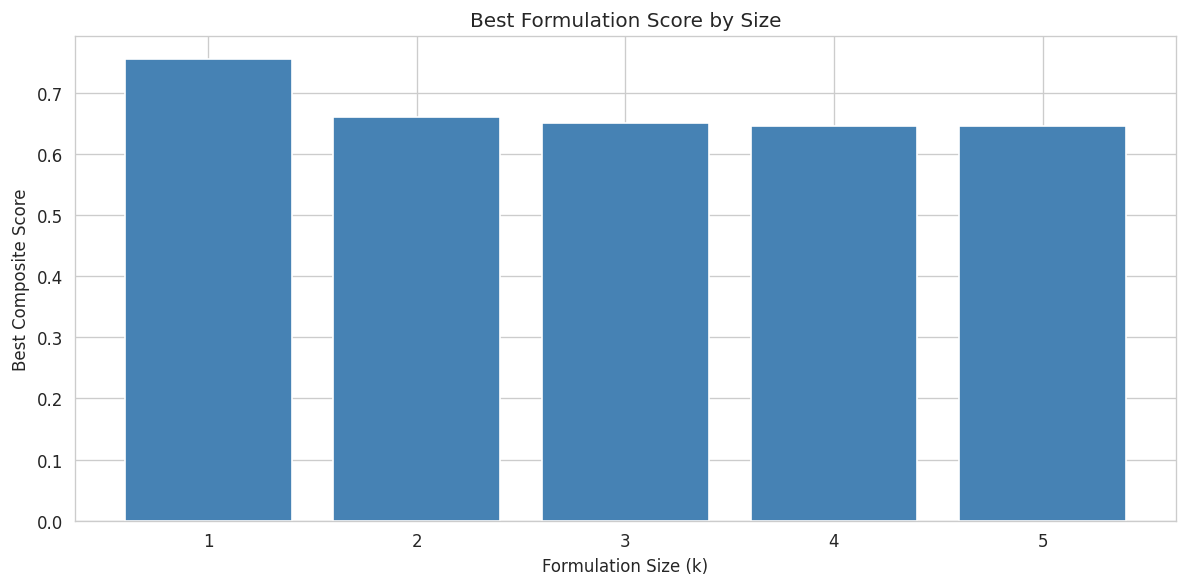

In [8]:
# Scores by formulation size
print('Best formulation per size:')
for k in range(1, 6):
    fk = formulations[formulations.k == k]
    if len(fk) > 0:
        best = fk.nlargest(1, 'composite_score').iloc[0]
        print(f'  k={k}: {len(fk)} formulations, best composite={best.composite_score:.3f}, '
              f'coverage={best.niche_coverage:.0%}, inh={best.mean_inhibition:.0f}%')

# Simple bar chart instead of line plot (avoids shape mismatch issues)
fig, ax = plt.subplots(figsize=(10, 5))
k_vals, scores_vals = [], []
for k in range(1, 6):
    fk = formulations[formulations.k == k]
    if len(fk) > 0:
        k_vals.append(k)
        scores_vals.append(fk.composite_score.max())
ax.bar(k_vals, scores_vals, color='steelblue')
ax.set_xlabel('Formulation Size (k)')
ax.set_ylabel('Best Composite Score')
ax.set_title('Best Formulation Score by Size')
ax.set_xticks(k_vals)
plt.tight_layout()
plt.savefig(FIGS / '05_formulation_scores_by_size.png', dpi=150, bbox_inches='tight')
plt.show()
